📂 Model Yolu: /kaggle/input/safespeech-model/best_model_v2.keras
📂 Test Verisi Yolu: /kaggle/input/timit-ready/TIMIT_READY/TEST
✅ Model Başarıyla Yüklendi!

🧪 Test Verisi Taranıyor ve Tahmin Yapılıyor...
   📂 FEMALE işleniyor (560 dosya)...


100%|██████████| 560/560 [00:38<00:00, 14.43it/s]


   📂 MALE işleniyor (1120 dosya)...


100%|██████████| 1120/1120 [01:20<00:00, 13.86it/s]



✅ Toplam İşlenen Dosya: 1680

📊 Grafikler Çiziliyor...


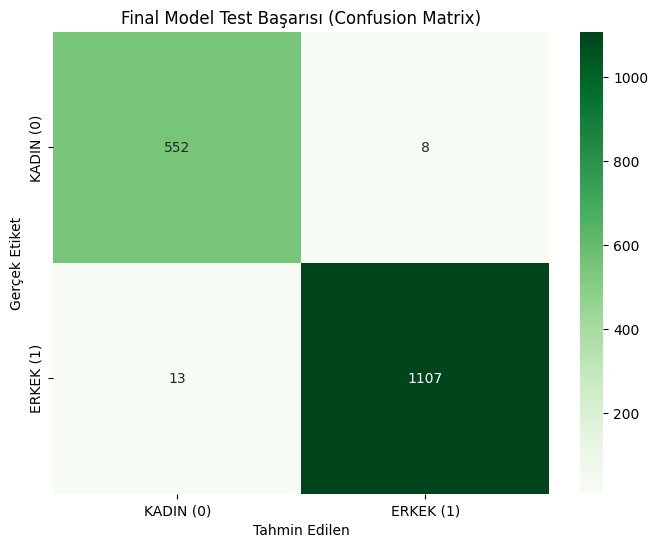


📝 Detaylı Sınıflandırma Raporu:
------------------------------------------------------------
              precision    recall  f1-score   support

       KADIN       0.98      0.99      0.98       560
       ERKEK       0.99      0.99      0.99      1120

    accuracy                           0.99      1680
   macro avg       0.98      0.99      0.99      1680
weighted avg       0.99      0.99      0.99      1680

------------------------------------------------------------
🏆 TEST SETİ FİNAL DOĞRULUĞU: %98.75


In [2]:
import os
import numpy as np
import tensorflow as tf
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm

MODEL_PATH = "/kaggle/input/safespeech-model/best_model_v2.keras"
TEST_DIR = "/kaggle/input/timit-ready/TIMIT_READY/TEST"

# Parametreler
SAMPLE_RATE = 16000
IMG_SIZE = (128, 128)
DURATION = 5

print(f"📂 Model Yolu: {MODEL_PATH}")
print(f"📂 Test Verisi Yolu: {TEST_DIR}")

# --- MODELİ YÜKLE ---
if not os.path.exists(MODEL_PATH):
    print("❌ HATA: Model dosyası bulunamadı! Yolu kontrol et.")
else:
    try:
        model = tf.keras.models.load_model(MODEL_PATH)
        print("✅ Model Başarıyla Yüklendi!")
        #model.summary() 
    except Exception as e:
        print(f"❌ Model yüklenirken hata oluştu: {e}")

# --- ÖNİŞLEME FONKSİYONU ---
def preprocess_audio_file(file_path):
    try:
        audio, sr = librosa.load(file_path, sr=SAMPLE_RATE)
        max_len = SAMPLE_RATE * DURATION
        if len(audio) > max_len:
            audio = audio[:max_len]
        else:
            padding = max_len - len(audio)
            audio = np.pad(audio, (0, padding), 'constant')
            
        # Tensor Dönüşümü
        audio_tensor = tf.convert_to_tensor(audio, dtype=tf.float32)
        
        # STFT -> Spectrogram -> Log
        spectrogram = tf.signal.stft(audio_tensor, frame_length=255, frame_step=128)
        spectrogram = tf.abs(spectrogram)
        spectrogram = tf.math.log(spectrogram + 1e-6)
        
        # Boyutlandırma (128x128) ve Kanal Ekleme
        spectrogram = tf.expand_dims(spectrogram, axis=-1)
        spectrogram = tf.image.resize(spectrogram, IMG_SIZE)
        
        # Modelin beklediği batch boyutu (1, 128, 128, 1)
        spectrogram = tf.expand_dims(spectrogram, axis=0)
        
        return spectrogram
    except Exception as e:
        print(f"Dosya okuma hatası: {file_path}") 
        return None

# --- TEST VERİSİNİ TARA VE TAHMİN YAP ---
print("\n🧪 Test Verisi Taranıyor ve Tahmin Yapılıyor...")

y_true = []
y_pred = []
files_processed = 0

categories = {'FEMALE': 0, 'MALE': 1} 

for category, label in categories.items():
    folder_path = os.path.join(TEST_DIR, category)
    
    if not os.path.exists(folder_path):
        print(f"⚠️ UYARI: {folder_path} klasörü bulunamadı.")
        folder_path = os.path.join(TEST_DIR, category.lower())
        if os.path.exists(folder_path):
            print(f"   -> Klasör küçük harfle bulundu: {folder_path}")
        else:
            continue 
            
    files = os.listdir(folder_path)
    print(f"   📂 {category} işleniyor ({len(files)} dosya)...")
    
    for file_name in tqdm(files):
        if file_name.lower().endswith(('.wav', '.mp3', '.flac')):
            file_path = os.path.join(folder_path, file_name)
            
            # Önişleme
            spec = preprocess_audio_file(file_path)
            
            if spec is not None:
                # Tahmin (Batch size=1)
                prediction = model.predict(spec, verbose=0)
                
                # Sigmoid çıktısı: >0.5 ise Erkek(1), değilse Kadın(0)
                predicted_label = 1 if prediction[0][0] > 0.5 else 0
                
                y_true.append(label)
                y_pred.append(predicted_label)
                files_processed += 1

print(f"\n✅ Toplam İşlenen Dosya: {files_processed}")

# --- SONUÇLARI GÖRSELLEŞTİR (CONFUSION MATRIX) ---
if files_processed > 0:
    print("\n📊 Grafikler Çiziliyor...")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
                xticklabels=['KADIN (0)', 'ERKEK (1)'], 
                yticklabels=['KADIN (0)', 'ERKEK (1)'])
    plt.xlabel('Tahmin Edilen')
    plt.ylabel('Gerçek Etiket')
    plt.title('Final Model Test Başarısı (Confusion Matrix)')
    plt.show()

    # --- SINIFLANDIRMA RAPORU ---
    print("\n📝 Detaylı Sınıflandırma Raporu:")
    print("-" * 60)
    print(classification_report(y_true, y_pred, target_names=['KADIN', 'ERKEK']))
    print("-" * 60)

    # --- GENEL DOĞRULUK ---
    accuracy = np.sum(np.array(y_true) == np.array(y_pred)) / len(y_true)
    print(f"🏆 TEST SETİ FİNAL DOĞRULUĞU: %{accuracy * 100:.2f}")
else:
    print("❌ Hiçbir dosya işlenemedi. Klasör yollarını veya dosya uzantılarını kontrol et.")

In [4]:
import os
import random
import numpy as np
import librosa
import tensorflow as tf
from IPython.display import Audio, display

print("🔀 Rastgele 'Mix & Stream' Testi Hazırlanıyor...")

# --- AYARLAR ---
SILENCE_DURATION = 5  
SAMPLE_RATE = 16000
TEST_DIR = "/kaggle/input/timit-ready/TIMIT_READY/TEST" 

# --- FONKSİYON: DOSYALARI GÜVENLİ TOPLA ---
def get_files_safe(base_dir, category_name):
    target_path = os.path.join(base_dir, category_name)
    if not os.path.exists(target_path):
        target_path = os.path.join(base_dir, category_name.lower()) 
    
    if not os.path.exists(target_path):
        print(f"⚠️ UYARI: {category_name} klasörü bulunamadı!")
        return []

    # 2. Dosyaları topla (.wav, .mp3, .WAV vb.)
    all_files = os.listdir(target_path)
    valid_files = [
        os.path.join(target_path, f) 
        for f in all_files 
        if f.lower().endswith(('.wav', '.mp3', '.flac'))
    ]
    return valid_files

# --- DOSYALARI ÇEK ---
female_files = get_files_safe(TEST_DIR, 'FEMALE')
male_files = get_files_safe(TEST_DIR, 'MALE')

print(f"   📂 Bulunan Kadın Sesi: {len(female_files)}")
print(f"   📂 Bulunan Erkek Sesi: {len(male_files)}")

# Hata önleyici kontrol: Eğer hiç dosya yoksa durdur.
if len(female_files) == 0 or len(male_files) == 0:
    raise ValueError("❌ Klasörlerde ses dosyası bulunamadı! Lütfen TEST_DIR yolunu kontrol et.")

# --- RASTGELE SEÇİM (HATA VERMEYEN VERSİYON) ---
count_f = min(10, len(female_files))
count_m = min(10, len(male_files))

selected_females = random.sample(female_files, count_f)
selected_males = random.sample(male_files, count_m)


playlist = [(f, 'KADIN') for f in selected_females] + [(f, 'ERKEK') for f in selected_males]
random.shuffle(playlist)

print(f"✅ Toplam {len(playlist)} dosya seçildi ve karıştırıldı.")

# --- SESLERİ BİRLEŞTİR ---
long_audio = []
ground_truth_timeline = [] 
current_sample = 0
silence_chunk = np.zeros(int(SAMPLE_RATE * SILENCE_DURATION)) 

for file_path, label in playlist:
    long_audio.extend(silence_chunk)
    current_sample += len(silence_chunk)
    
    try:
        y, _ = librosa.load(file_path, sr=SAMPLE_RATE)
        norm_factor = np.max(np.abs(y))
        if norm_factor > 0:
            y = y / norm_factor
        
        start_time = current_sample / SAMPLE_RATE
        long_audio.extend(y)
        current_sample += len(y)
        end_time = current_sample / SAMPLE_RATE
        
        ground_truth_timeline.append({
            "start": start_time,
            "end": end_time,
            "label": label,
            "audio_chunk": y
        })
    except Exception as e:
        print(f"Hatalı dosya atlandı: {file_path}")

long_audio = np.array(long_audio)
print(f"📼 Uzun Kayıt Oluşturuldu! Süre: {len(long_audio)/SAMPLE_RATE:.1f} saniye")

# --- MODEL SİMÜLASYONU ---
print("\n🧪 Model Simülasyonu Başlıyor...")
print(f"{'ZAMAN ARALIĞI':<20} | {'GERÇEK':<10} | {'TAHMİN':<10} | {'OLASILIK':<10} | {'DURUM'}")
print("-" * 80)

correct_count = 0

for item in ground_truth_timeline:
    chunk = item["audio_chunk"]
    
    max_len = SAMPLE_RATE * 5
    if len(chunk) > max_len:
        chunk = chunk[:max_len]
    else:
        padding = max_len - len(chunk)
        chunk = np.pad(chunk, (0, padding), 'constant')
        
    chunk_tensor = tf.convert_to_tensor(chunk, dtype=tf.float32)
    spec = tf.signal.stft(chunk_tensor, frame_length=255, frame_step=128)
    spec = tf.abs(spec)
    spec = tf.math.log(spec + 1e-6)
    spec = tf.expand_dims(spec, axis=-1)
    spec = tf.image.resize(spec, (128, 128))
    spec = tf.expand_dims(spec, axis=0)
    
    # Tahmin
    pred = model.predict(spec, verbose=0)
    prob = pred[0][0]
    pred_label = "ERKEK" if prob > 0.5 else "KADIN"
    
    # Kontrol
    is_correct = "✅" if pred_label == item["label"] else "❌"
    if is_correct == "✅": correct_count += 1
    
    confidence = prob if pred_label == "ERKEK" else 1 - prob
    
    print(f"{item['start']:.1f}s - {item['end']:.1f}s     | {item['label']:<10} | {pred_label:<10} | %{confidence*100:.1f}      | {is_correct}")

print("-" * 80)
print(f"🏆 SKOR: {correct_count}/{len(ground_truth_timeline)} Doğru Tahmin")

🔀 Rastgele 'Mix & Stream' Testi Hazırlanıyor...
   📂 Bulunan Kadın Sesi: 560
   📂 Bulunan Erkek Sesi: 1120
✅ Toplam 20 dosya seçildi ve karıştırıldı.
📼 Uzun Kayıt Oluşturuldu! Süre: 159.3 saniye

🧪 Model Simülasyonu Başlıyor...
ZAMAN ARALIĞI        | GERÇEK     | TAHMİN     | OLASILIK   | DURUM
--------------------------------------------------------------------------------
5.0s - 7.3s     | ERKEK      | ERKEK      | %100.0      | ✅
12.3s - 15.0s     | KADIN      | KADIN      | %100.0      | ✅
20.0s - 22.0s     | ERKEK      | ERKEK      | %100.0      | ✅
27.0s - 29.8s     | KADIN      | KADIN      | %100.0      | ✅
34.8s - 37.8s     | KADIN      | KADIN      | %100.0      | ✅
42.8s - 45.5s     | KADIN      | KADIN      | %100.0      | ✅
50.5s - 53.3s     | ERKEK      | ERKEK      | %100.0      | ✅
58.3s - 62.6s     | ERKEK      | ERKEK      | %100.0      | ✅
67.6s - 69.7s     | ERKEK      | ERKEK      | %100.0      | ✅
74.7s - 77.9s     | KADIN      | KADIN      | %99.3      | ✅
82.9s 